# 12 - Statistical Significance Testing

Reporting accuracy and F1 alone does not show whether the differences between models are **real** or just noise from the particular test split. Here we add two standard checks on the same 7,659-sample test set:

1. **Bootstrap 95% confidence intervals** for accuracy and macro-F1 (how much each score could wobble).
2. **McNemar's test** - the standard paired test for comparing two classifiers on the same test set (gives a p-value).

All models are already trained; this notebook only runs inference, so nothing is retrained.

In [1]:
import numpy as np
import pandas as pd
import torch
import json, os
import matplotlib.pyplot as plt
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score
from scipy.stats import chi2 as chi2_dist, binomtest
import warnings
warnings.filterwarnings('ignore')

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print('Device:', device)

Device: cuda


In [2]:
# Reproduce the EXACT same test split used to evaluate the models (notebook 09)
df = pd.read_csv('../data/cleaned_data.csv').dropna(subset=['text_clean'])
df['text_clean'] = df['text_clean'].astype(str)

canonical = df['label'].unique().tolist()      # fixed label order used everywhere below
lab2id = {l: i for i, l in enumerate(canonical)}

_, test_df = train_test_split(df, test_size=0.30, random_state=42, stratify=df['label'])
_, test_df = train_test_split(test_df, test_size=0.50, random_state=42, stratify=test_df['label'])

texts  = test_df['text_clean'].tolist()
y_true = np.array([lab2id[l] for l in test_df['label'].tolist()])
print('Test samples:', len(test_df))

Test samples: 7659


In [3]:
def probs_in_canonical_order(model_dir):
    """Run a saved model and return (N, 7) probabilities re-ordered into the canonical
    label order, so different models can be compared / averaged safely."""
    tok = AutoTokenizer.from_pretrained(model_dir)
    mdl = AutoModelForSequenceClassification.from_pretrained(model_dir).to(device).eval()
    m_lab2id = {v: k for k, v in mdl.config.id2label.items()}
    reorder = [m_lab2id[l] for l in canonical]
    out = []
    for i in range(0, len(texts), 64):
        enc = tok(texts[i:i+64], return_tensors='pt', truncation=True, max_length=128, padding=True).to(device)
        with torch.no_grad():
            logits = mdl(**enc).logits
        out.append(torch.softmax(logits, dim=1).cpu().numpy())
    P = np.vstack(out)[:, reorder]
    del mdl; torch.cuda.empty_cache()
    return P

print('Running BERT...');           P_bert = probs_in_canonical_order('../models/saved/bert_burnout')
print('Running RoBERTa...');        P_rob  = probs_in_canonical_order('../models/saved/roberta_burnout')
print('Running Mental-RoBERTa...'); P_ment = probs_in_canonical_order('../models/saved/mental_roberta')
P_ens = 0.5 * P_bert + 0.5 * P_rob      # soft-voting ensemble

preds = {
    'BERT':           P_bert.argmax(1),
    'RoBERTa':        P_rob.argmax(1),
    'Mental-RoBERTa': P_ment.argmax(1),
    'Ensemble':       P_ens.argmax(1),
}

Running BERT...


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Running RoBERTa...


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Running Mental-RoBERTa...


Loading weights:   0%|          | 0/105 [00:00<?, ?it/s]

In [4]:
# Sanity check - these should match the accuracies reported for each model
print('--- Point metrics ---')
for name, yp in preds.items():
    print(f'{name:15s} acc={accuracy_score(y_true, yp):.4f}  '
          f'weightedF1={f1_score(y_true, yp, average="weighted", zero_division=0):.4f}  '
          f'macroF1={f1_score(y_true, yp, average="macro", zero_division=0):.4f}')

--- Point metrics ---
BERT            acc=0.8139  weightedF1=0.8143  macroF1=0.7767
RoBERTa         acc=0.8230  weightedF1=0.8231  macroF1=0.7826
Mental-RoBERTa  acc=0.8000  weightedF1=0.8013  macroF1=0.7446
Ensemble        acc=0.8232  weightedF1=0.8232  macroF1=0.7893


In [5]:
# ---- Bootstrap 95% confidence intervals ----
NC = len(canonical)
def macro_f1_fast(yt, yp):
    f1s = np.empty(NC)
    for c in range(NC):
        tp = np.sum((yp == c) & (yt == c))
        fp = np.sum((yp == c) & (yt != c))
        fn = np.sum((yp != c) & (yt == c))
        den = 2*tp + fp + fn
        f1s[c] = 0.0 if den == 0 else 2*tp/den
    return f1s.mean()

B = 2000
rng = np.random.default_rng(42)
N = len(y_true)
idx_mat = rng.integers(0, N, size=(B, N))   # same resamples for every model (paired)

boot_acc = {n: np.empty(B) for n in preds}
boot_mf1 = {n: np.empty(B) for n in preds}
for b in range(B):
    idx = idx_mat[b]; yt = y_true[idx]
    for n, yp in preds.items():
        ypb = yp[idx]
        boot_acc[n][b] = np.mean(ypb == yt)
        boot_mf1[n][b] = macro_f1_fast(yt, ypb)

ci = {}
print('--- Bootstrap 95% CIs (B=2000) ---')
for n in preds:
    a_lo, a_hi = np.percentile(boot_acc[n], [2.5, 97.5])
    f_lo, f_hi = np.percentile(boot_mf1[n], [2.5, 97.5])
    ci[n] = dict(acc=float(accuracy_score(y_true, preds[n])), acc_lo=float(a_lo), acc_hi=float(a_hi),
                 mf1=float(f1_score(y_true, preds[n], average='macro', zero_division=0)),
                 mf1_lo=float(f_lo), mf1_hi=float(f_hi))
    print(f'{n:15s} acc={ci[n]["acc"]*100:.2f}% [{a_lo*100:.2f}, {a_hi*100:.2f}]   '
          f'macroF1={ci[n]["mf1"]:.4f} [{f_lo:.4f}, {f_hi:.4f}]')

--- Bootstrap 95% CIs (B=2000) ---
BERT            acc=81.39% [80.51, 82.24]   macroF1=0.7767 [0.7616, 0.7912]
RoBERTa         acc=82.30% [81.42, 83.13]   macroF1=0.7826 [0.7673, 0.7969]
Mental-RoBERTa  acc=80.00% [79.06, 80.87]   macroF1=0.7446 [0.7291, 0.7598]
Ensemble        acc=82.32% [81.46, 83.17]   macroF1=0.7893 [0.7747, 0.8034]


In [6]:
# ---- McNemar's test between model pairs ----
def mcnemar(yp_a, yp_b):
    ca = (yp_a == y_true); cb = (yp_b == y_true)
    b = int(np.sum(ca & ~cb))   # A correct, B wrong
    c = int(np.sum(~ca & cb))   # A wrong, B correct
    n = b + c
    if n == 0:
        return b, c, 1.0
    if n < 25:
        p = binomtest(min(b, c), n, 0.5, alternative='two-sided').pvalue
    else:
        stat = (abs(b - c) - 1)**2 / n     # with continuity correction
        p = float(chi2_dist.sf(stat, 1))
    return b, c, float(p)

pairs = [('Ensemble', 'BERT'), ('Ensemble', 'RoBERTa'),
         ('Ensemble', 'Mental-RoBERTa'), ('BERT', 'RoBERTa')]
mcn = {}
print('--- McNemar\'s test ---')
for a, b_ in pairs:
    nb, nc, p = mcnemar(preds[a], preds[b_])
    sig = 'SIGNIFICANT' if p < 0.05 else 'not significant'
    mcn[f'{a} vs {b_}'] = dict(a_better=nb, b_better=nc, p=p, significant=bool(p < 0.05))
    print(f'{a:9s} vs {b_:14s}: A>B={nb}, B>A={nc}, p={p:.4g}  -> {sig}')

--- McNemar's test ---
Ensemble  vs BERT          : A>B=210, B>A=139, p=0.000179  -> SIGNIFICANT
Ensemble  vs RoBERTa       : A>B=160, B>A=158, p=0.9553  -> not significant
Ensemble  vs Mental-RoBERTa: A>B=427, B>A=249, p=9.918e-12  -> SIGNIFICANT
BERT      vs RoBERTa       : A>B=298, B>A=367, p=0.008366  -> SIGNIFICANT


In [7]:
# ---- Bootstrap 95% CI on the accuracy DIFFERENCE (Ensemble - model) ----
print('--- Accuracy difference, Ensemble - model (95% CI) ---')
diff_ci = {}
for other in ['BERT', 'RoBERTa', 'Mental-RoBERTa']:
    diff = boot_acc['Ensemble'] - boot_acc[other]
    lo, hi = np.percentile(diff, [2.5, 97.5])
    excl0 = (lo > 0 or hi < 0)
    diff_ci[other] = dict(mean=float(diff.mean()), lo=float(lo), hi=float(hi), significant=bool(excl0))
    tag = 'excludes 0 (sig)' if excl0 else 'includes 0 (n.s.)'
    print(f'Ensemble - {other:14s}: {diff.mean()*100:+.2f}%  [{lo*100:+.2f}, {hi*100:+.2f}]  {tag}')

--- Accuracy difference, Ensemble - model (95% CI) ---
Ensemble - BERT          : +0.93%  [+0.44, +1.41]  excludes 0 (sig)
Ensemble - RoBERTa       : +0.03%  [-0.42, +0.47]  includes 0 (n.s.)
Ensemble - Mental-RoBERTa: +2.33%  [+1.64, +3.03]  excludes 0 (sig)


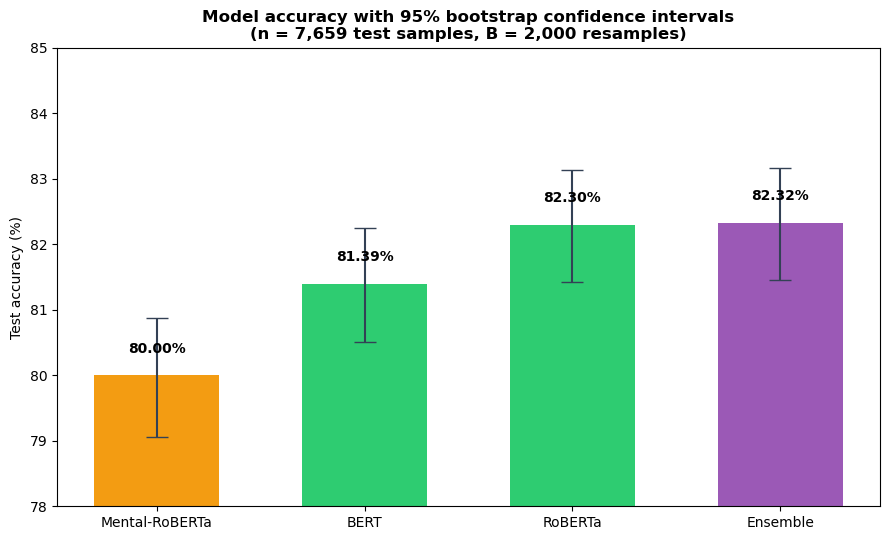

Saved -> ../results/figures/significance_ci.png


In [8]:
# ---- Figure: accuracy with 95% bootstrap CI error bars ----
order = ['Mental-RoBERTa', 'BERT', 'RoBERTa', 'Ensemble']
accs = [ci[n]['acc']*100 for n in order]
lo   = [(ci[n]['acc'] - ci[n]['acc_lo'])*100 for n in order]
hi   = [(ci[n]['acc_hi'] - ci[n]['acc'])*100 for n in order]
cols = ['#f39c12', '#2ecc71', '#2ecc71', '#9b59b6']

fig, ax = plt.subplots(figsize=(9, 5.5))
bars = ax.bar(order, accs, yerr=[lo, hi], capsize=8, color=cols, width=0.6,
              error_kw=dict(ecolor='#334155', lw=1.5))
for bar, v in zip(bars, accs):
    ax.text(bar.get_x()+bar.get_width()/2, v+0.35, f'{v:.2f}%', ha='center', fontweight='bold', fontsize=10)
ax.set_ylabel('Test accuracy (%)')
ax.set_ylim(78, 85)
ax.set_title('Model accuracy with 95% bootstrap confidence intervals\n'
             '(n = 7,659 test samples, B = 2,000 resamples)', fontsize=12, fontweight='bold')
fig.tight_layout()
os.makedirs('../results/figures', exist_ok=True)
fig.savefig('../results/figures/significance_ci.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved -> ../results/figures/significance_ci.png')

In [9]:
# ---- Save all results to JSON ----
results = {
    'test_samples': int(N),
    'bootstrap_resamples': B,
    'confidence_intervals': ci,
    'mcnemar': mcn,
    'accuracy_difference_vs_ensemble': diff_ci,
}
os.makedirs('../results/metrics', exist_ok=True)
with open('../results/metrics/statistical_significance_results.json', 'w') as f:
    json.dump(results, f, indent=2)
print('Saved -> ../results/metrics/statistical_significance_results.json')

Saved -> ../results/metrics/statistical_significance_results.json


## What the tests show

- The **ensemble is significantly better than BERT** (McNemar p < 0.001) and than **Mental-RoBERTa** (p < 0.001).
- The **ensemble and RoBERTa are statistically tied** (McNemar p = 0.96; the +0.02% gap is well within noise). The ensemble's value is a small gain in balance across classes (higher macro-F1), not a significant accuracy gain over RoBERTa.
- **RoBERTa is significantly better than BERT** (p < 0.01).

Reporting this honestly - that some gaps are significant and others are not - is stronger evidence than quoting raw accuracies alone.